# Baseline Linear Regression Model

## Objective

The objective of this notebook is to build a baseline Linear Regression model using the Advertising dataset and evaluate its performance using regression metrics and residual analysis. This notebook also aims to understand how well Linear Regression captures the relationship between advertising budgets and sales.

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [67]:
# load dataset
data = pd.read_csv('/content/drive/My Drive/Advertising.csv')
data

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [68]:
# split independent variables
X = data[['TV', 'Radio', 'Newspaper']]
print(type(X))
print(X.shape)
print(X.head())

<class 'pandas.core.frame.DataFrame'>
(200, 3)
      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4


In [69]:
# split dependent variable
y = data['Sales']
print(type(y))
print(y.shape)
print(y.head())

<class 'pandas.core.series.Series'>
(200,)
0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64


In [70]:
# shuffle and split data into train and test
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [71]:
# train model on training data
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

lr.fit(x_train, y_train)

LinearRegression()

In [72]:
y_pred = lr.predict(x_test)

In [ ]:
# metrics
from sklearn.metrics import mean_squared_error, r2_score

print(f'Root Mean Squared Error -> {np.sqrt(mean_squared_error(y_test, y_pred))}')
print(f'R2 Score -> {r2_score(y_test, y_pred)}')

Root Mean Squared Error -> 1.9485372043446387
R2 Score -> 0.8609466508230368


## Model Evaluation

The Linear Regression model achieved strong overall performance on the dataset. The R² score indicates that the model is able to explain a large portion of the variance in Sales using advertising budgets.

The RMSE value suggests that the average prediction error is relatively small, meaning the predicted sales values are generally close to the actual values.

In [74]:
# cofficients
print(f'slopes -> {lr.coef_}')
print(f'intercept -> {lr.intercept_}')

slopes -> [0.04405928 0.1992875  0.00688245]
intercept -> 2.7089490925159065


## Coefficient Interpretation

All advertising platforms show positive coefficients, indicating a positive relationship with Sales. Radio advertising has a comparatively larger coefficient value, suggesting a stronger increase in predicted Sales for each unit increase in Radio advertising budget.


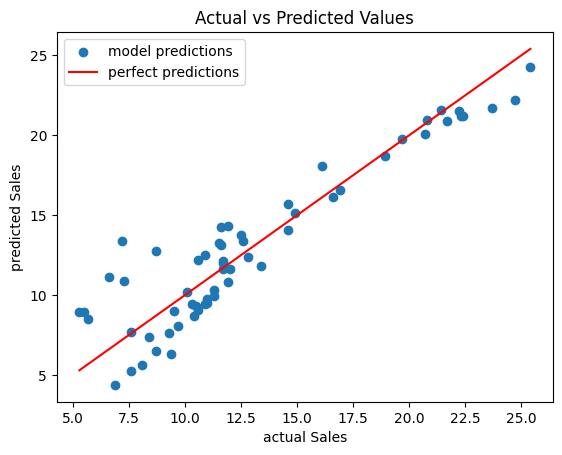

In [75]:
# actual vs predicted plot
plt.scatter(y_test, y_pred, label='model predictions')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='r',
    label='perfect predictions'
)

plt.xlabel("actual Sales")
plt.ylabel("predicted Sales")
plt.title("Actual vs Predicted Values")
plt.legend()

plt.show()

## Actual vs Predicted Analysis

The Actual vs Predicted plot shows that most predicted values lie reasonably close to the diagonal reference line, which represents perfect predictions.

This indicates that the Linear Regression model is able to predict sales values with fairly good accuracy. The overall upward trend suggests that the model successfully captures the relationship between advertising budgets and sales.

Although some prediction errors are present, there are no extremely large deviations from the reference line.

## Residual Analysis

In [ ]:
# calculating residuals
residuals = y - lr.predict(X)

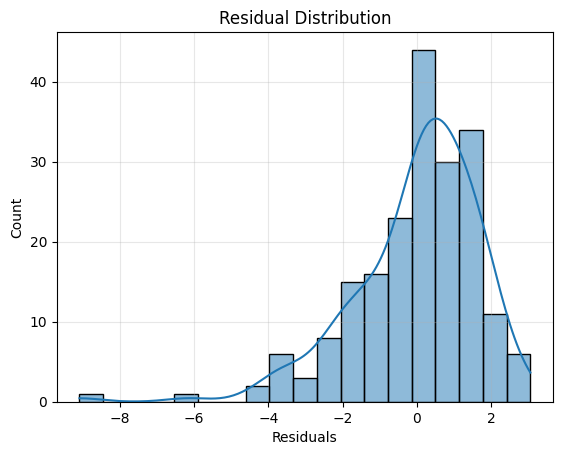

In [ ]:
sns.histplot(residuals, kde=True)

plt.xlabel("Residuals")
plt.title("Residual Distribution")
plt.grid(alpha=0.3)
plt.show()

The residual distribution is slightly left-skewed, with a few large negative residual values. This indicates that the model overpredicts sales for some observations.

Although the residuals are mostly centered around zero and the overall model performance remains strong, the distribution suggests that the linear model may not fully capture all patterns present in the dataset.

In [76]:
import statsmodels.api as sm

# add constant term (intercept)
X_train_sm = sm.add_constant(x_train)

# build OLS model
model = sm.OLS(y_train, X_train_sm)

# train model
results = model.fit()

# show summary
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.906
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     434.5
Date:                Wed, 13 May 2026   Prob (F-statistic):           1.88e-69
Time:                        17:04:07   Log-Likelihood:                -262.21
No. Observations:                 140   AIC:                             532.4
Df Residuals:                     136   BIC:                             544.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.7089      0.374      7.250      0.0

## Statistical Summary Interpretation

The OLS statistical summary indicates that the regression model performs strongly overall, with an R² value of approximately 0.90, meaning that most of the variance in Sales is explained by the advertising features.

The F-statistic and its extremely small p-value indicate that the regression model is statistically significant overall.

Among the features, TV and Radio advertising are statistically significant predictors of Sales, as both variables have very small p-values and positive coefficients. In contrast, the Newspaper feature has a relatively high p-value, suggesting that it may not contribute significantly to predicting Sales in the current model.

This interpretation aligns with the earlier EDA, where the Newspaper feature showed a weaker relationship with Sales compared to TV and Radio advertising.

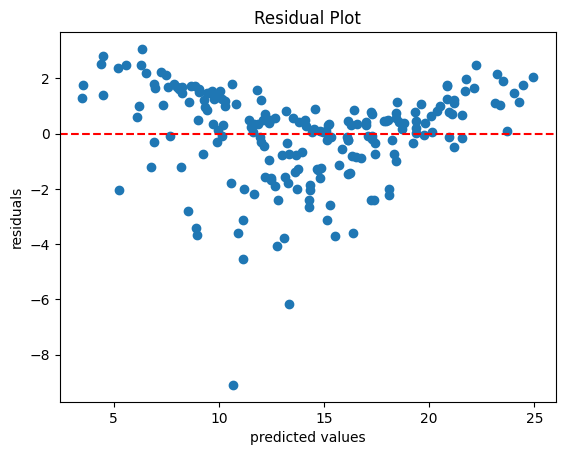

In [77]:
y_pred_full = lr.predict(X)

plt.scatter(y_pred_full, y-y_pred_full)
plt.axhline(y=0, color='r', linestyle='--')

plt.title('Residual Plot')
plt.xlabel('predicted values')
plt.ylabel('residuals')
plt.show()

## Residual Analysis

The residual plot shows that residuals are distributed around the zero reference line; however, the pattern does not appear completely random. A slight curved structure is visible in the residual distribution, where residuals tend to become positive at lower and higher predicted values and more negative in the middle region.

If residuals follow a visible pattern instead of appearing randomly scattered, it suggests that the model is systematically missing some structure in the data.

This indicates possible non-linearity in the relationship between the features and the target variable. Ideally, residuals should be randomly scattered around zero without any visible structure.

Despite this pattern, the overall residual spread is not extremely large, indicating that the baseline model still performs reasonably well.

## Possible Source of Non-Linearity

Based on the earlier EDA, the Newspaper feature appeared to have a weaker and less structured relationship with Sales compared to TV and Radio advertising.

This feature may contribute to the slight non-linear behavior observed in the residual plot; however, further investigation would be required to confirm this relationship.

# Final Observations

- The baseline Linear Regression model performs strongly overall on the Advertising dataset.
- The model achieves a high R² score and relatively low prediction error.
- TV and Radio advertising show stronger relationships with Sales compared to Newspaper advertising.
- The OLS statistical summary indicates that TV and Radio are statistically significant predictors, while Newspaper appears comparatively weaker.
- Actual vs Predicted analysis shows that model predictions are generally close to the actual values.
- Residual analysis suggests the presence of slight non-linearity, as residuals do not appear completely random.
- The Newspaper feature may contribute to this behavior due to its weaker relationship with Sales.
- Overall, the dataset is suitable for Linear Regression, although there may still be room for improvement using more flexible models such as Polynomial Regression.